In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/linking-writing-processes-to-writing-quality/sample_submission.csv
/kaggle/input/linking-writing-processes-to-writing-quality/test_logs.csv
/kaggle/input/linking-writing-processes-to-writing-quality/train_scores.csv
/kaggle/input/linking-writing-processes-to-writing-quality/train_logs.csv


In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats as stats
import warnings
pd.options.display.max_columns=None 

In [2]:
test = pd.read_csv('/kaggle/input/linking-writing-processes-to-writing-quality/test_logs.csv')
test.head() 

,id,event_id,down_time,up_time,action_time,activity,down_event,up_event,text_change,cursor_position,word_count
0,0000aaaa,1,338433,338518,85,Input,Space,Space,,0,0
1,0000aaaa,2,760073,760160,87,Input,Space,Space,,1,0
2,2222bbbb,1,711956,712023,67,Input,q,q,q,0,1
3,2222bbbb,2,290502,290548,46,Input,q,q,q,1,1
4,4444cccc,1,635547,635641,94,Input,Space,Space,,0,0


In [3]:
train = pd.read_csv('/kaggle/input/linking-writing-processes-to-writing-quality/train_logs.csv')
train.head()

,id,event_id,down_time,up_time,action_time,activity,down_event,up_event,text_change,cursor_position,word_count
0,001519c8,1,4526,4557,31,Nonproduction,Leftclick,Leftclick,NoChange,0,0
1,001519c8,2,4558,4962,404,Nonproduction,Leftclick,Leftclick,NoChange,0,0
2,001519c8,3,106571,106571,0,Nonproduction,Shift,Shift,NoChange,0,0
3,001519c8,4,106686,106777,91,Input,q,q,q,1,1
4,001519c8,5,107196,107323,127,Input,q,q,q,2,1


In [4]:
train1 = pd.read_csv('/kaggle/input/linking-writing-processes-to-writing-quality/train_scores.csv')
train1.head() 

,id,score
0,001519c8,3.5
1,0022f953,3.5
2,0042269b,6.0
3,0059420b,2.0
4,0075873a,4.0


In [5]:
combined = pd.concat([test,train,train1])
combined.head()

,id,event_id,down_time,up_time,action_time,activity,down_event,up_event,text_change,cursor_position,word_count,score
0,0000aaaa,1.0,338433.0,338518.0,85.0,Input,Space,Space,,0.0,0.0,NaN
1,0000aaaa,2.0,760073.0,760160.0,87.0,Input,Space,Space,,1.0,0.0,NaN
2,2222bbbb,1.0,711956.0,712023.0,67.0,Input,q,q,q,0.0,1.0,NaN
3,2222bbbb,2.0,290502.0,290548.0,46.0,Input,q,q,q,1.0,1.0,NaN
4,4444cccc,1.0,635547.0,635641.0,94.0,Input,Space,Space,,0.0,0.0,NaN


In [7]:
combined.info()

<class 'pandas.core.frame.DataFrame'>
Index: 8408375 entries, 0 to 2470
Data columns (total 12 columns):
 #   Column           Dtype  
---  ------           -----  
 0   id               object 
 1   event_id         float64
 2   down_time        float64
 3   up_time          float64
 4   action_time      float64
 5   activity         object 
 6   down_event       object 
 7   up_event         object 
 8   text_change      object 
 9   cursor_position  float64
 10  word_count       float64
 11  score            float64
dtypes: float64(7), object(5)
memory usage: 834.0+ MB


In [8]:
combined.dtypes

id                  object
event_id           float64
down_time          float64
up_time            float64
action_time        float64
activity            object
down_event          object
up_event            object
text_change         object
cursor_position    float64
word_count         float64
score              float64
dtype: object

In [9]:
combined.columns

Index(['id', 'event_id', 'down_time', 'up_time', 'action_time', 'activity',
       'down_event', 'up_event', 'text_change', 'cursor_position',
       'word_count', 'score'],
      dtype='object')

In [10]:
combined.describe().T

,count,mean,std,min,25%,50%,75%,max
event_id,8405904.0,2067.647859,1588.284191,1.0,852.00,1726.0,2926.00,12876.0
down_time,8405904.0,793560.070699,514944.973174,106.0,373184.00,720886.0,1163041.25,8313630.0
up_time,8405904.0,793658.155663,514942.682445,252.0,373281.75,720980.0,1163140.25,8313707.0
action_time,8405904.0,98.084964,253.398373,0.0,66.00,93.0,122.00,447470.0
cursor_position,8405904.0,1222.963580,948.524456,0.0,499.00,1043.0,1706.00,7802.0
word_count,8405904.0,231.468582,175.908886,0.0,96.00,200.0,327.00,1326.0
score,2471.0,3.711251,1.024937,0.5,3.00,4.0,4.50,6.0


In [11]:
combined.shape

(8408375, 12)

In [12]:
combined.isnull().sum()/len(combined)*100

id                  0.000000
event_id            0.029387
down_time           0.029387
up_time             0.029387
action_time         0.029387
activity            0.029387
down_event          0.029387
up_event            0.029387
text_change         0.029387
cursor_position     0.029387
word_count          0.029387
score              99.970613
dtype: float64

In [13]:
combined.kurt

<bound method NDFrame._add_numeric_operations.<locals>.kurt of             id  event_id  down_time   up_time  action_time activity  \
0     0000aaaa       1.0   338433.0  338518.0         85.0    Input   
1     0000aaaa       2.0   760073.0  760160.0         87.0    Input   
2     2222bbbb       1.0   711956.0  712023.0         67.0    Input   
3     2222bbbb       2.0   290502.0  290548.0         46.0    Input   
4     4444cccc       1.0   635547.0  635641.0         94.0    Input   
...        ...       ...        ...       ...          ...      ...   
2466  ffb8c745       NaN        NaN       NaN          NaN      NaN   
2467  ffbef7e5       NaN        NaN       NaN          NaN      NaN   
2468  ffccd6fd       NaN        NaN       NaN          NaN      NaN   
2469  ffec5b38       NaN        NaN       NaN          NaN      NaN   
2470  fff05981       NaN        NaN       NaN          NaN      NaN   

     down_event up_event text_change  cursor_position  word_count  score  
0        

In [14]:
combined.skew

<bound method NDFrame._add_numeric_operations.<locals>.skew of             id  event_id  down_time   up_time  action_time activity  \
0     0000aaaa       1.0   338433.0  338518.0         85.0    Input   
1     0000aaaa       2.0   760073.0  760160.0         87.0    Input   
2     2222bbbb       1.0   711956.0  712023.0         67.0    Input   
3     2222bbbb       2.0   290502.0  290548.0         46.0    Input   
4     4444cccc       1.0   635547.0  635641.0         94.0    Input   
...        ...       ...        ...       ...          ...      ...   
2466  ffb8c745       NaN        NaN       NaN          NaN      NaN   
2467  ffbef7e5       NaN        NaN       NaN          NaN      NaN   
2468  ffccd6fd       NaN        NaN       NaN          NaN      NaN   
2469  ffec5b38       NaN        NaN       NaN          NaN      NaN   
2470  fff05981       NaN        NaN       NaN          NaN      NaN   

     down_event up_event text_change  cursor_position  word_count  score  
0        

<Axes: >

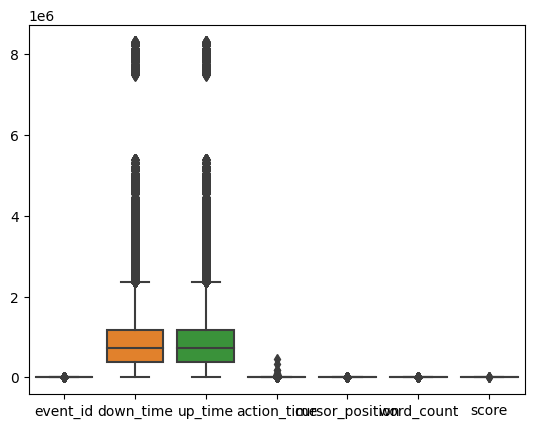

In [15]:
sns.boxplot(combined)

<Axes: >

/opt/conda/lib/python3.10/site-packages/IPython/core/events.py:93: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  func(*args, **kwargs)
/opt/conda/lib/python3.10/site-packages/IPython/core/pylabtools.py:152: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


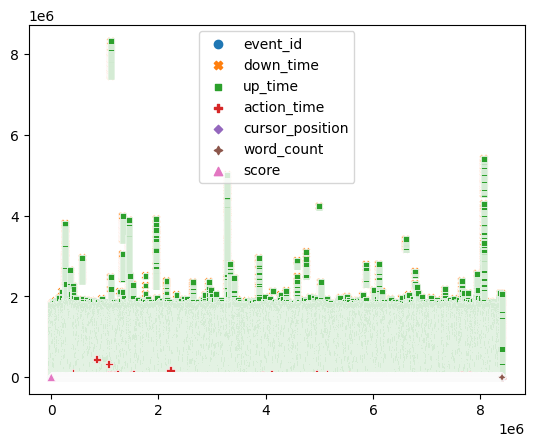

In [16]:
sns.scatterplot(combined)

<Axes: >

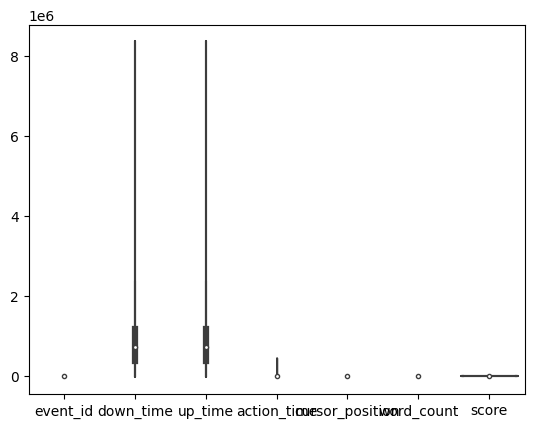

In [17]:
sns.violinplot(combined)

<Axes: ylabel='Density'>

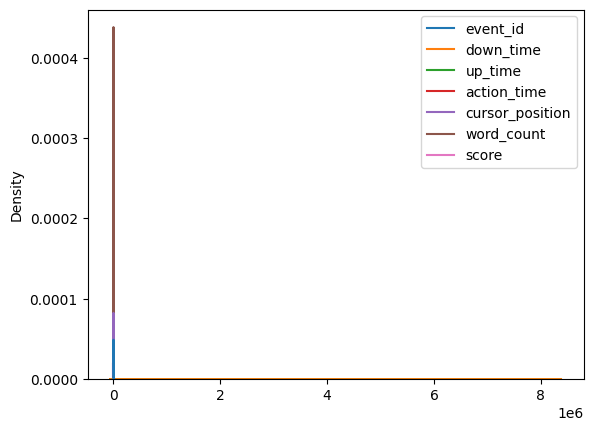

In [7]:
sns.kdeplot(combined) 

In [7]:
cat_cols = combined.select_dtypes(include='object')

In [8]:
for i in cat_cols:
    print(i)
    data=(combined[i].value_counts())
    print(''*50)
    

id

activity

down_event

up_event

text_change



In [9]:
num_cols = combined.select_dtypes(include='number')

In [10]:
for i in num_cols:
    print(i)
    data=(combined[i].value_counts())
    print(''*50)

event_id

down_time

up_time

action_time

cursor_position

word_count

score



In [ ]:
plt.figure(figsize=(12,10))
sns.barplot(data=combined,palette='mako');
plt.xticks(rotation=45);


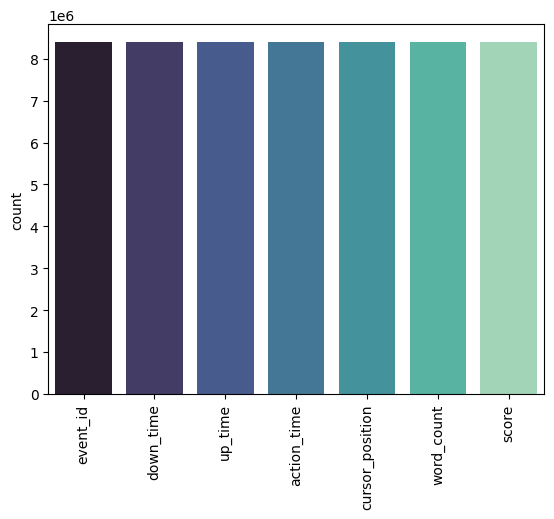

In [12]:
sns.countplot(data=combined,palette='mako');
plt.xticks(rotation=90);

In [ ]:
plt.figure(figsize=(10,11))
sns.barplot(data=combined,palette='mako');
plt.xtikcs(rotation=90)
           

In [14]:
#  Treating type of event_id
combined['event_id'].value_counts().head(9).index[1:] 

Index([2.0, 174.0, 180.0, 179.0, 178.0, 177.0, 176.0, 175.0], dtype='float64', name='event_id')

In [17]:
combined.shape

(8408375, 12)

In [16]:
combined.head() 

,id,event_id,down_time,up_time,action_time,activity,down_event,up_event,text_change,cursor_position,word_count,score
0,0000aaaa,1.0,338433.0,338518.0,85.0,Input,Space,Space,,0.0,0.0,NaN
1,0000aaaa,2.0,760073.0,760160.0,87.0,Input,Space,Space,,1.0,0.0,NaN
2,2222bbbb,1.0,711956.0,712023.0,67.0,Input,q,q,q,0.0,1.0,NaN
3,2222bbbb,2.0,290502.0,290548.0,46.0,Input,q,q,q,1.0,1.0,NaN
4,4444cccc,1.0,635547.0,635641.0,94.0,Input,Space,Space,,0.0,0.0,NaN


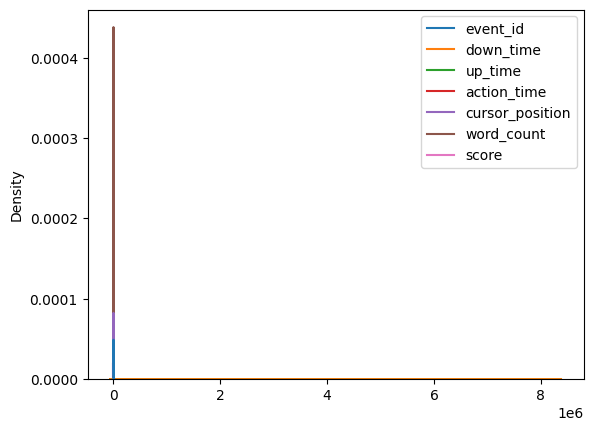

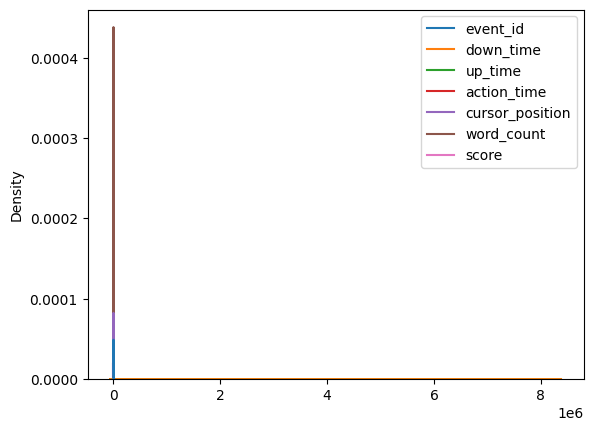

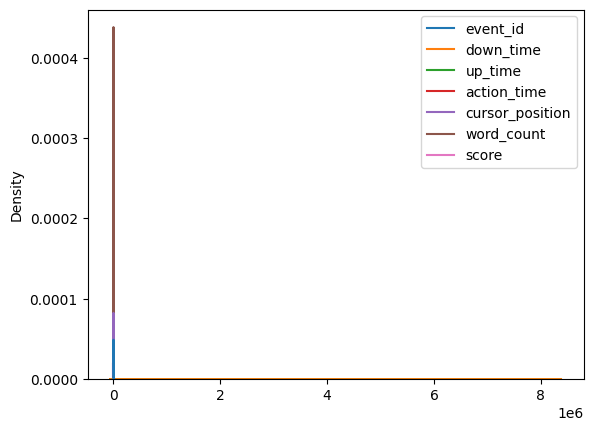

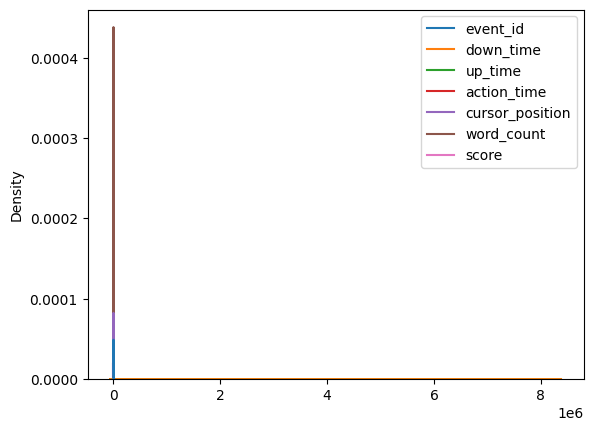

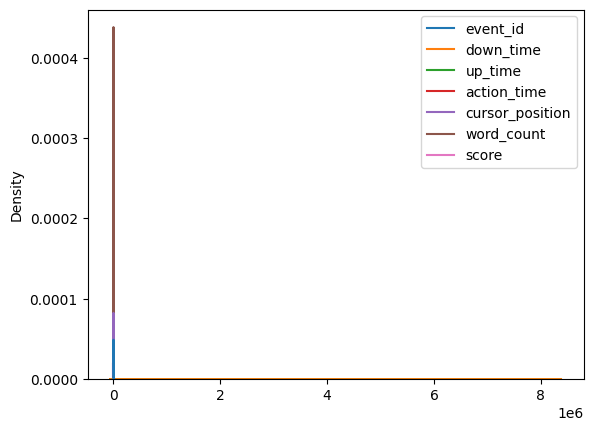

In [20]:
x = i
cat_cols = combined.select_dtypes(include='object')
for i in cat_cols:
    sns.kdeplot(data=combined)
    print('\n') 
    plt.show() 


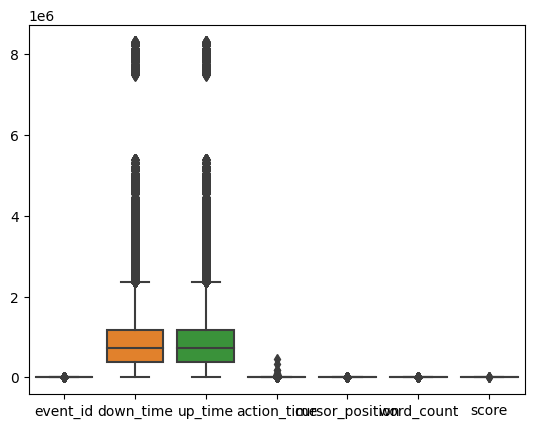

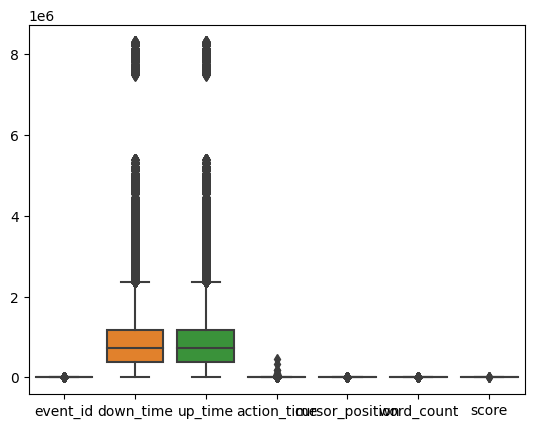

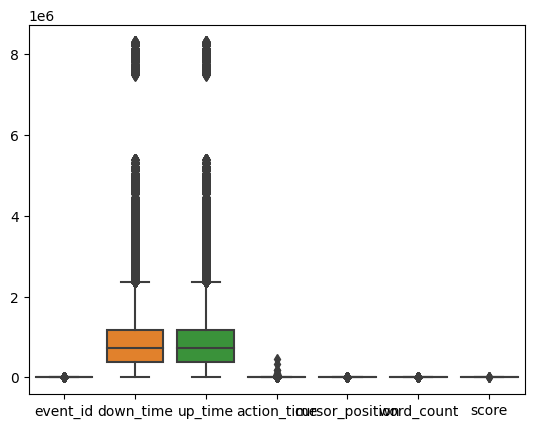

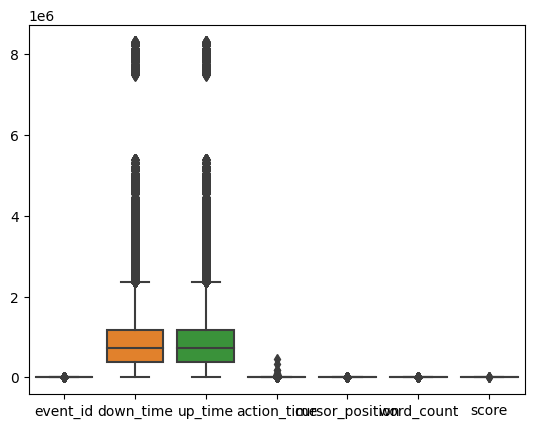

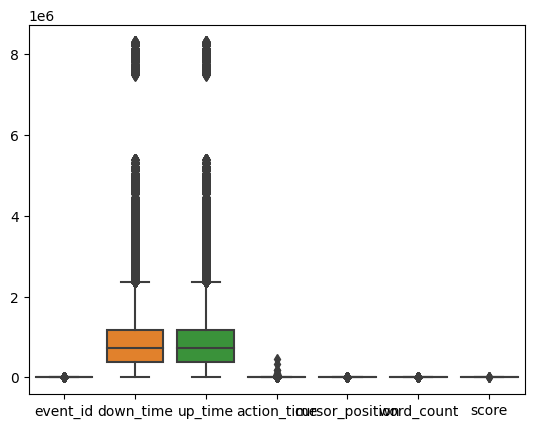

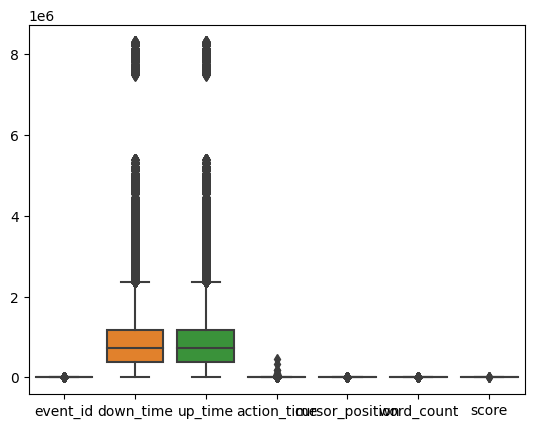

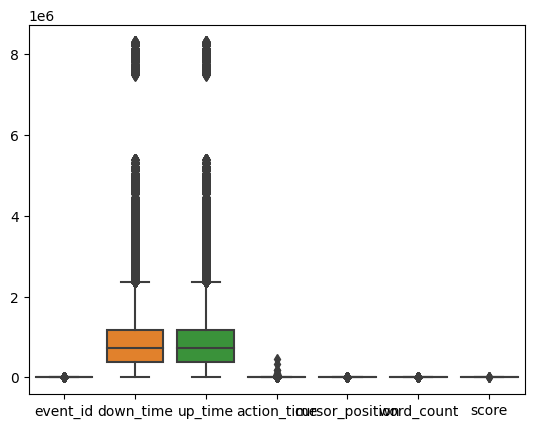

In [47]:
x = i
num_cols = combined.select_dtypes(include='number')
for i in num_cols:
    sns.boxplot(data=combined)
    print('\n')
    plt.show()


In [48]:
x = combined[['down_time']]

In [39]:
y = combined[['down_time']]

In [40]:
from sklearn.model_selection import train_test_split

In [41]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.3)

In [42]:
from sklearn.linear_model import LinearRegression

In [43]:
lr = LinearRegression()